# **1. Import Library**

In [238]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# **2. Data Loading**

In [239]:
path = '../data/raw/dataset_modelling_waste.csv'

df_raw = pd.read_csv(path)

df_raw.head()

,tanggal,jenis_sampah,berat_kg,densitas_kg_m3
0,2026-04-18,Aluminium,0.24,190
1,2026-04-18,Kertas,8.22,150
2,2026-04-18,Emberan,9.03,68
3,2026-04-18,Emberan,0.19,68
4,2026-04-19,Campuran,0.33,150


# **3. Data Cleaning**

In [240]:
df_raw['tanggal'] = pd.to_datetime(df_raw['tanggal'])

In [241]:
df_raw.isnull().sum()

tanggal           0
jenis_sampah      0
berat_kg          0
densitas_kg_m3    0
dtype: int64

In [242]:
df_raw.duplicated().sum()

# Duplikat diabaikan karena itu kemiripan transaksi nasabah yang berbeda tetapi menyetor sampah dan jumlah yang sama

np.int64(8)

In [243]:
# Menampilkan semua baris yang terindikasi duplikat (asli + kembaraannya) 
# Diabaikan karena itu kemiripan transaksi nasabah yang berbeda tetapi menyetor sampah dan jumlah yang sama
df_raw[df_raw.duplicated(keep=False)].sort_values(by='tanggal')

,tanggal,jenis_sampah,berat_kg,densitas_kg_m3
6,2026-04-20,Beling/Botol,0.00,60
17,2026-04-20,Beling/Botol,0.00,60
79,2026-04-25,Kaleng,0.62,120
89,2026-04-25,Kaleng,0.62,120
180,2026-05-05,Beling/Botol,0.01,60
184,2026-05-05,Beling/Botol,0.00,60
189,2026-05-05,Beling/Botol,0.01,60
195,2026-05-05,Beling/Botol,0.00,60
331,2026-05-19,Beling/Botol,0.01,60
335,2026-05-19,Beling/Botol,0.01,60


In [244]:
df_raw['volume_m3'] = df_raw['berat_kg'] / df_raw['densitas_kg_m3']

# Cek hasilnya
df_raw.head()

,tanggal,jenis_sampah,berat_kg,densitas_kg_m3,volume_m3
0,2026-04-18,Aluminium,0.24,190,0.001263
1,2026-04-18,Kertas,8.22,150,0.054800
2,2026-04-18,Emberan,9.03,68,0.132794
3,2026-04-18,Emberan,0.19,68,0.002794
4,2026-04-19,Campuran,0.33,150,0.002200


In [245]:
df_clean = df_raw.drop(columns=['densitas_kg_m3'])

df_clean

,tanggal,jenis_sampah,berat_kg,volume_m3
0,2026-04-18,Aluminium,0.24,0.001263
1,2026-04-18,Kertas,8.22,0.054800
2,2026-04-18,Emberan,9.03,0.132794
3,2026-04-18,Emberan,0.19,0.002794
4,2026-04-19,Campuran,0.33,0.002200
...,...,...,...,...
561,2026-06-15,Kertas,1.32,0.008800
562,2026-06-15,Emberan,8.08,0.118824
563,2026-06-15,Beling/Botol,0.02,0.000333
564,2026-06-15,Emberan,13.35,0.196324


In [246]:
kondisi_inf = (df_clean['volume_m3'] > 10)
indeks_yang_dihapus = df_clean[kondisi_inf].index

df_clean[kondisi_inf]

,tanggal,jenis_sampah,berat_kg,volume_m3


In [247]:
df_clean.drop(indeks_yang_dihapus, inplace=True)

In [248]:
df_clean['tanggal'] = pd.to_datetime(df_clean['tanggal'])

In [249]:
df_daily = df_clean.groupby('tanggal').agg({
    'berat_kg': 'sum',
    'volume_m3': 'sum'
}).reset_index()

df_daily = df_daily.sort_values(by='tanggal').reset_index(drop=True)

df_daily

,tanggal,berat_kg,volume_m3
0,2026-04-18,17.68,0.191651
1,2026-04-19,0.67,0.004467
2,2026-04-20,35.42,0.590406
3,2026-04-21,67.05,0.487233
4,2026-04-22,60.20,0.546106
5,2026-04-23,18.48,0.293353
6,2026-04-24,13.79,0.197420
7,2026-04-25,36.78,0.699706
8,2026-04-27,39.52,0.764762
9,2026-04-28,18.90,0.508306


# **4. Exploratory Data Analysis (EDA)**

In [250]:
df_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   tanggal    50 non-null     datetime64[ns]
 1   berat_kg   50 non-null     float64       
 2   volume_m3  50 non-null     float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 1.3 KB


In [251]:
df_daily.describe()

,tanggal,berat_kg,volume_m3
count,50,50.00000,50.000000
mean,2026-05-15 22:33:36,26.66240,0.461746
min,2026-04-18 00:00:00,0.67000,0.004467
25%,2026-05-01 06:00:00,13.88500,0.198494
50%,2026-05-15 12:00:00,21.54500,0.378557
75%,2026-05-30 18:00:00,38.57250,0.663354
max,2026-06-15 00:00:00,76.40000,1.319716
std,NaN,18.61327,0.324334


## Tren Total Volume Sampah Harian

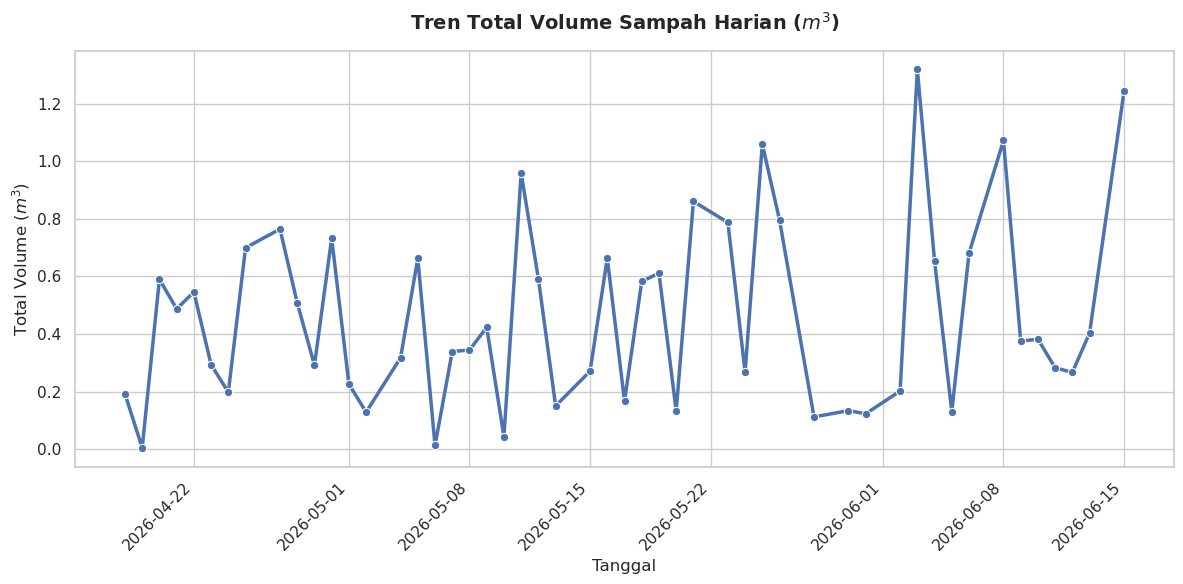

In [252]:
plt.figure(figsize=(12, 6))

sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_daily, 
    x='tanggal', 
    y='volume_m3', 
    marker='o',         
    color='b',          
    linewidth=2.5
)

plt.title('Tren Total Volume Sampah Harian ($m^3$)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Volume ($m^3$)', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Tren Total Volume Sampah Harian (Log Transform)

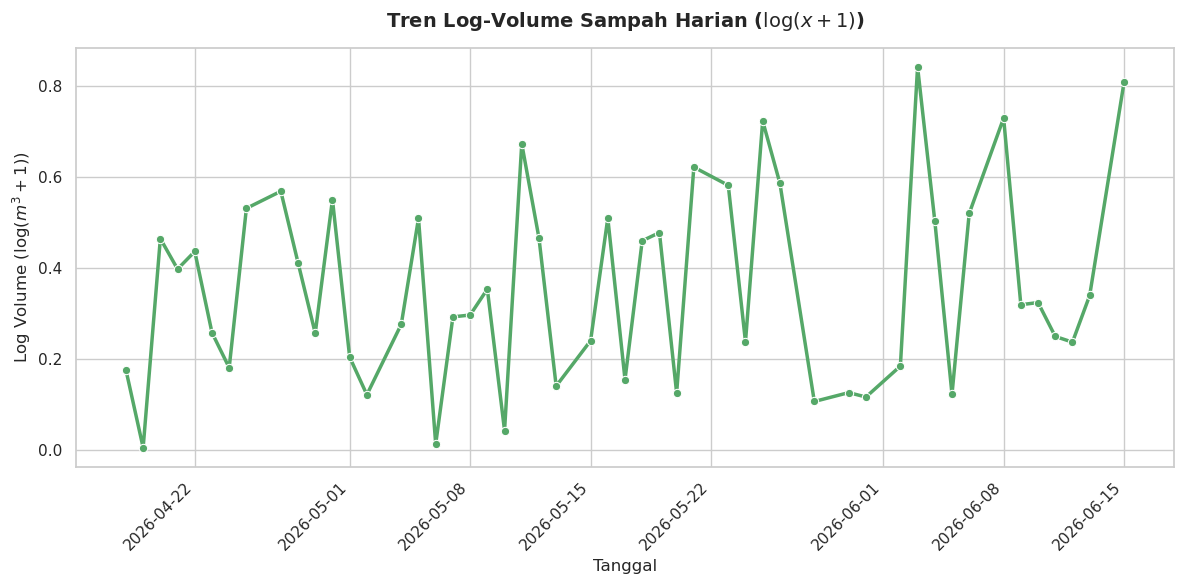

In [253]:
df_daily['log_volume_m3'] = np.log1p(df_daily['volume_m3'])

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_daily, 
    x='tanggal', 
    y='log_volume_m3', 
    marker='o', 
    color='g',           
    linewidth=2.5
)

plt.title('Tren Log-Volume Sampah Harian ($\log(x + 1)$)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Log Volume ($\log(m^3 + 1)$)', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Tren Total Berat Sampah Harian

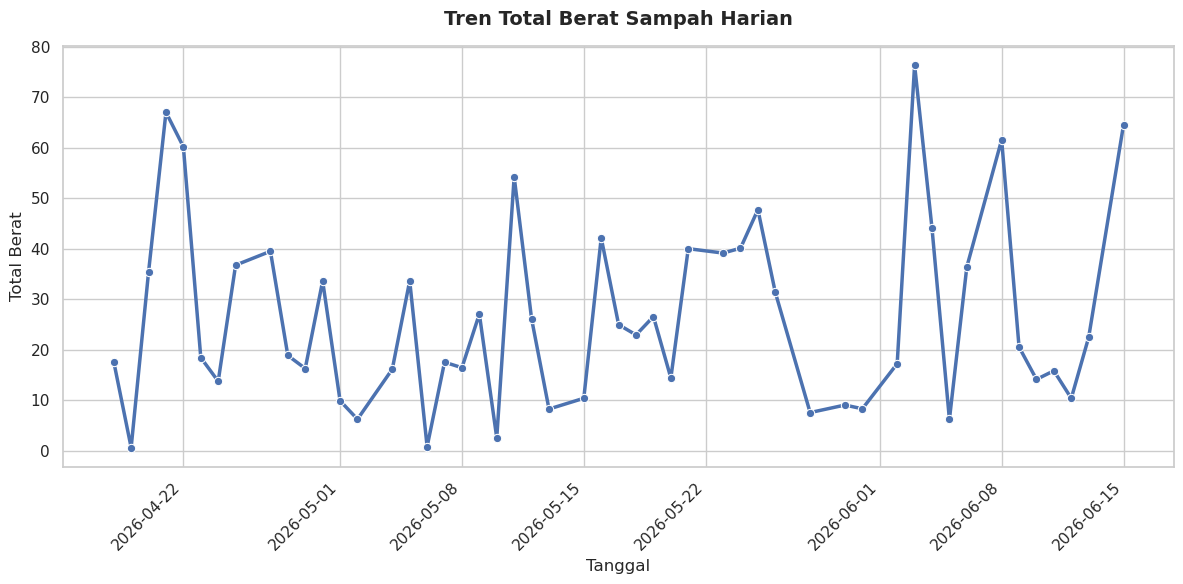

In [254]:
plt.figure(figsize=(12, 6))

sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_daily, 
    x='tanggal', 
    y='berat_kg', 
    marker='o',          
    color='b',           
    linewidth=2.5
)

plt.title('Tren Total Berat Sampah Harian', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Berat', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Tren Total Volume Sampah Harian (Log Transform)

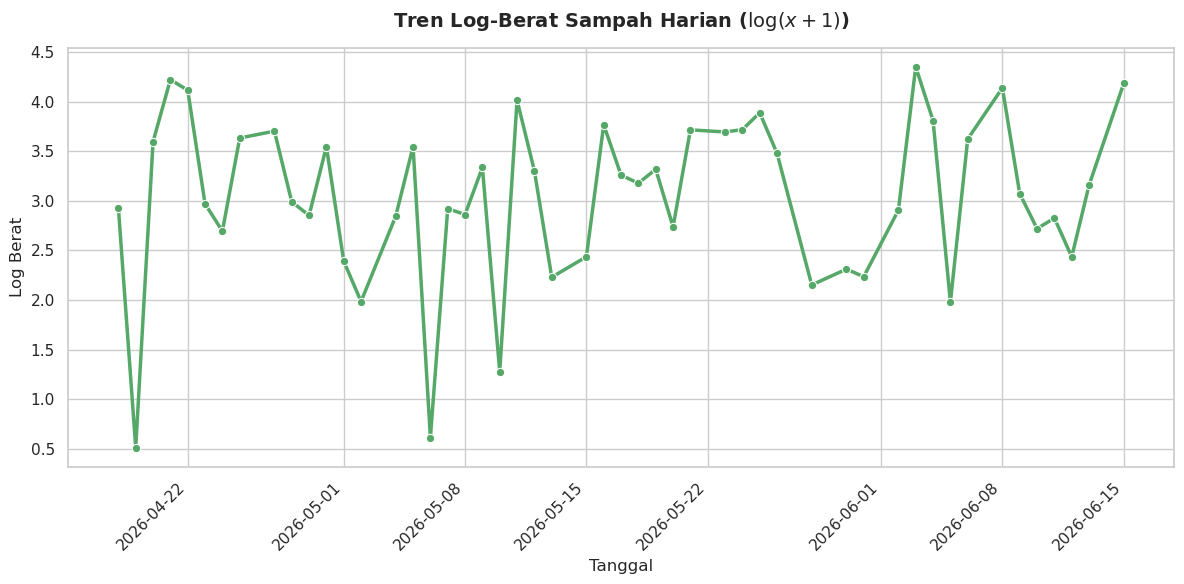

In [255]:
df_daily['log_berat'] = np.log1p(df_daily['berat_kg'])

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_daily, 
    x='tanggal', 
    y='log_berat', 
    marker='o', 
    color='g',           
    linewidth=2.5
)

plt.title('Tren Log-Berat Sampah Harian ($\log(x + 1)$)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Log Berat', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_17563/105523905.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_17563/105523905.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


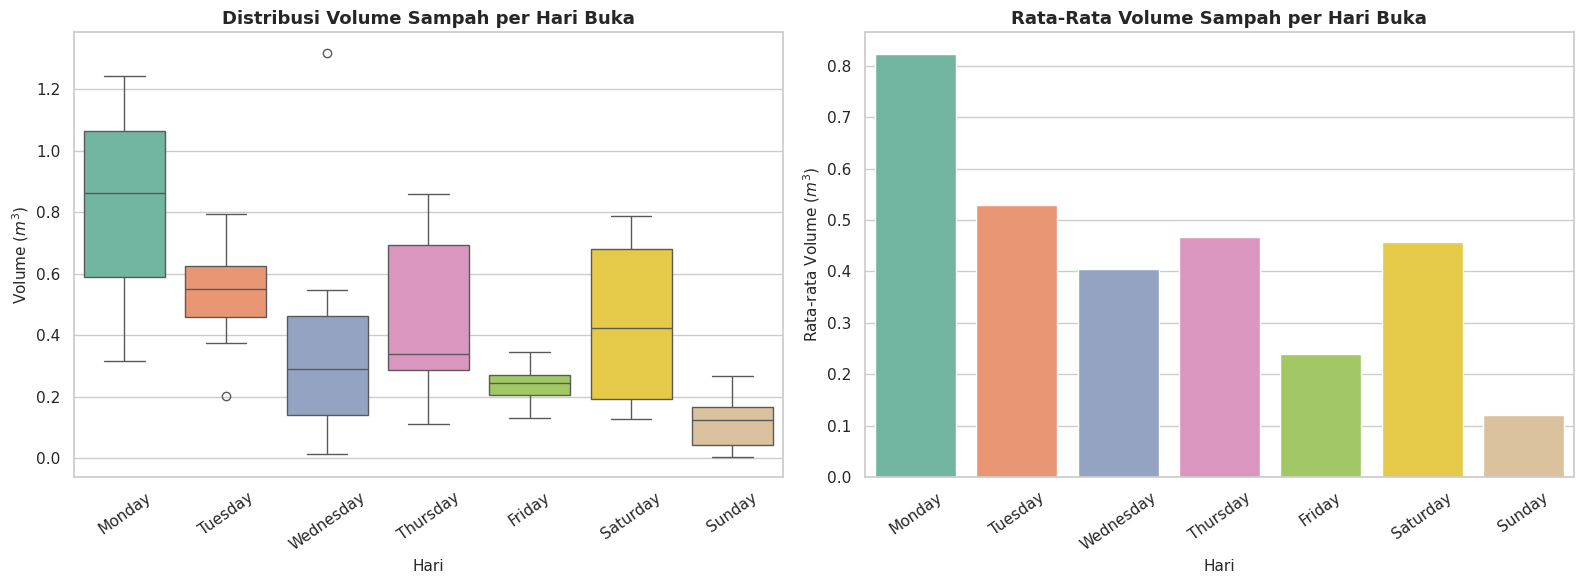

In [256]:
df_daily['nama_hari'] = df_daily['tanggal'].dt.day_name()

urutan_hari = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_daily['nama_hari'] = pd.Categorical(df_daily['nama_hari'], categories=urutan_hari, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

sns.boxplot(
    ax=axes[0],
    data=df_daily,
    x='nama_hari',
    y='volume_m3',
    palette='Set2'
)
axes[0].set_title('Distribusi Volume Sampah per Hari Buka', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hari', fontsize=11)
axes[0].set_ylabel('Volume ($m^3$)', fontsize=11)
axes[0].tick_params(axis='x', rotation=35)

sns.barplot(
    ax=axes[1],
    data=df_daily,
    x='nama_hari',
    y='volume_m3',
    estimator='mean', 
    errorbar=None,    
    palette='Set2'
)
axes[1].set_title('Rata-Rata Volume Sampah per Hari Buka', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hari', fontsize=11)
axes[1].set_ylabel('Rata-rata Volume ($m^3$)', fontsize=11)
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

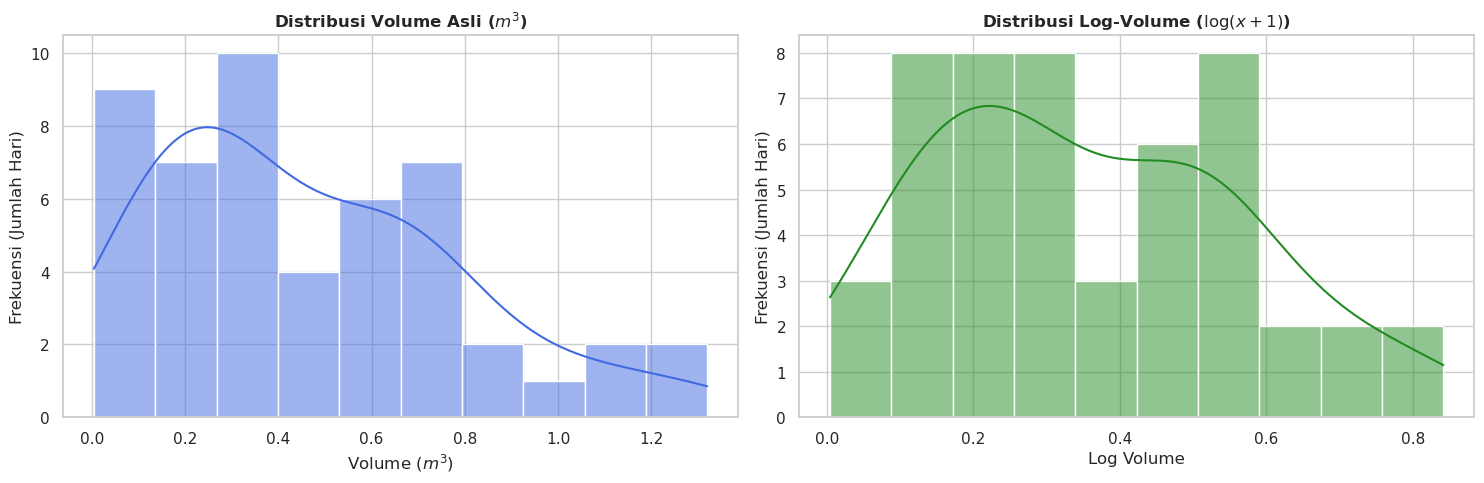

In [257]:
df_daily['log_volume_m3'] = np.log1p(df_daily['volume_m3'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.set_theme(style="whitegrid")

sns.histplot(
    ax=axes[0],
    data=df_daily,
    x='volume_m3',
    kde=True,          
    color='royalblue',
    bins=10            
)
axes[0].set_title('Distribusi Volume Asli ($m^3$)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Volume ($m^3$)')
axes[0].set_ylabel('Frekuensi (Jumlah Hari)')

sns.histplot(
    ax=axes[1],
    data=df_daily,
    x='log_volume_m3',
    kde=True,
    color='forestgreen',
    bins=10
)
axes[1].set_title('Distribusi Log-Volume ($\log(x+1)$)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log Volume')
axes[1].set_ylabel('Frekuensi (Jumlah Hari)')

plt.tight_layout()
plt.show()

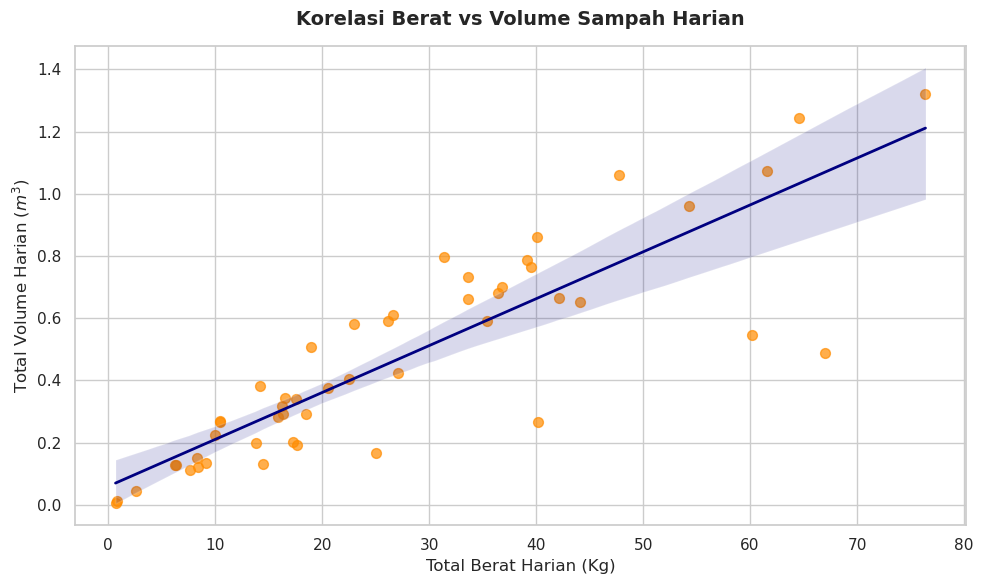

In [258]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.regplot(
    data=df_daily,
    x='berat_kg',
    y='volume_m3',
    scatter_kws={'s': 50, 'alpha': 0.7, 'color': 'darkorange'},
    line_kws={'color': 'navy', 'linewidth': 2}                 
)

plt.title('Korelasi Berat vs Volume Sampah Harian', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Berat Harian (Kg)', fontsize=12)
plt.ylabel('Total Volume Harian ($m^3$)', fontsize=12)

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

In [259]:
df_daily["tanggal"] = pd.to_datetime(df_daily["tanggal"])
df_daily = df_daily.sort_values(by="tanggal").reset_index(drop=True)

is_sunday = df_daily["tanggal"].dt.dayofweek == 6
df_daily.loc[is_sunday, "tanggal"] = df_daily.loc[
    is_sunday, "tanggal"
] + pd.to_timedelta(1, unit="D")

df_preprocessed = (
    df_daily.groupby("tanggal")
    .agg({"berat_kg": "sum", "volume_m3": "sum"})
    .reset_index()
)

df_preprocessed = df_preprocessed.sort_values(by="tanggal").reset_index(
    drop=True
)

df_preprocessed["is_monday"] = (
    df_preprocessed["tanggal"].dt.dayofweek == 0
).astype(int)

df_preprocessed["log_volume_m3"] = np.log1p(df_preprocessed["volume_m3"])

df_preprocessed = df_preprocessed.rename(columns={"berat": "berat_kg"})

print("--- REKAPITULASI PREPROCESSING ---")
print(f"1. Jumlah baris di database awal : {len(df_daily)} hari")
print(f"2. Jumlah baris setelah merger   : {len(df_preprocessed)} hari buka")
print("\nSampel data teratas setelah dibersihkan:")

df_preprocessed[
    ["tanggal", "berat_kg", "volume_m3", "is_monday", "log_volume_m3"]
].head(10)


--- REKAPITULASI PREPROCESSING ---
1. Jumlah baris di database awal : 50 hari
2. Jumlah baris setelah merger   : 46 hari buka

Sampel data teratas setelah dibersihkan:


,tanggal,berat_kg,volume_m3,is_monday,log_volume_m3
0,2026-04-18,17.68,0.191651,0,0.175340
1,2026-04-20,36.09,0.594873,1,0.466794
2,2026-04-21,67.05,0.487233,0,0.396918
3,2026-04-22,60.20,0.546106,0,0.435740
4,2026-04-23,18.48,0.293353,0,0.257238
5,2026-04-24,13.79,0.197420,0,0.180170
6,2026-04-25,36.78,0.699706,0,0.530455
7,2026-04-27,39.52,0.764762,1,0.568016
8,2026-04-28,18.90,0.508306,0,0.410987
9,2026-04-29,16.32,0.291714,0,0.255970


# **6. Save Dataset**

In [260]:
output_folder = "../data/processed"
os.makedirs(output_folder, exist_ok=True)

kolom_final = [
    "tanggal",
    "berat_kg",
    "volume_m3",
    "log_volume_m3",
    "is_monday",
]
df_final_eda = df_preprocessed[kolom_final]

file_name = "processed_waste_dataset.csv"
file_path = os.path.join(output_folder, file_name)

df_final_eda.to_csv(file_path, index=False)